In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Makes plots look nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)  

# Average daily temperature (°C) for 36 months
temperature = np.array([
    # Year 1
    18.2, 20.5, 25.3, 31.0, 36.4, 39.1,
    37.8, 36.2, 33.5, 28.7, 22.1, 17.4,
    # Year 2
    19.0, 21.2, 26.0, 32.1, 37.0, 40.3,
    38.5, 35.9, 34.0, 29.5, 23.0, 18.1,
    # Year 3
    17.8, 20.0, 24.8, 30.5, 35.9, 38.7,
    37.2, 36.8, 32.9, 27.4, 21.5, 16.9
])

# Monthly electricity bill (₹) — roughly follows: bill = 30*temp - 300 + noise
noise = np.random.normal(0, 80, size=len(temperature))
electricity_bill = 30 * temperature - 280 + noise
electricity_bill = np.round(electricity_bill, 2)

# Build a DataFrame
df = pd.DataFrame({
    'Month': pd.date_range(start='2022-01', periods=36, freq='MS').strftime('%b-%Y'),
    'Avg_Temperature_C': temperature,
    'Electricity_Bill_INR': electricity_bill
})

print(f"Dataset shape: {df.shape}")
print()
print(df.to_string(index=False))

Dataset shape: (36, 3)

   Month  Avg_Temperature_C  Electricity_Bill_INR
Jan-2022               18.2                305.74
Feb-2022               20.5                323.94
Mar-2022               25.3                530.82
Apr-2022               31.0                771.84
May-2022               36.4                793.27
Jun-2022               39.1                874.27
Jul-2022               37.8                980.34
Aug-2022               36.2                867.39
Sep-2022               33.5                687.44
Oct-2022               28.7                624.40
Nov-2022               22.1                345.93
Dec-2022               17.4                204.74
Jan-2023               19.0                309.36
Feb-2023               21.2                202.94
Mar-2023               26.0                362.01
Apr-2023               32.1                638.02
May-2023               37.0                748.97
Jun-2023               40.3                954.14
Jul-2023               38.

In [3]:
print("Basic Statistics")
print(df[['Avg_Temperature_C', 'Electricity_Bill_INR']].describe().round(2))

Basic Statistics
       Avg_Temperature_C  Electricity_Bill_INR
count              36.00                 36.00
mean               28.92                574.64
std                 7.75                259.50
min                16.90                129.33
25%                21.42                341.66
50%                30.00                631.21
75%                36.25                789.21
max                40.30                980.34


In [4]:
# Check for missing values
print("Missing Values")
print(df.isnull().sum())
print("\nNo missing values")

Missing Values
Month                   0
Avg_Temperature_C       0
Electricity_Bill_INR    0
dtype: int64

No missing values


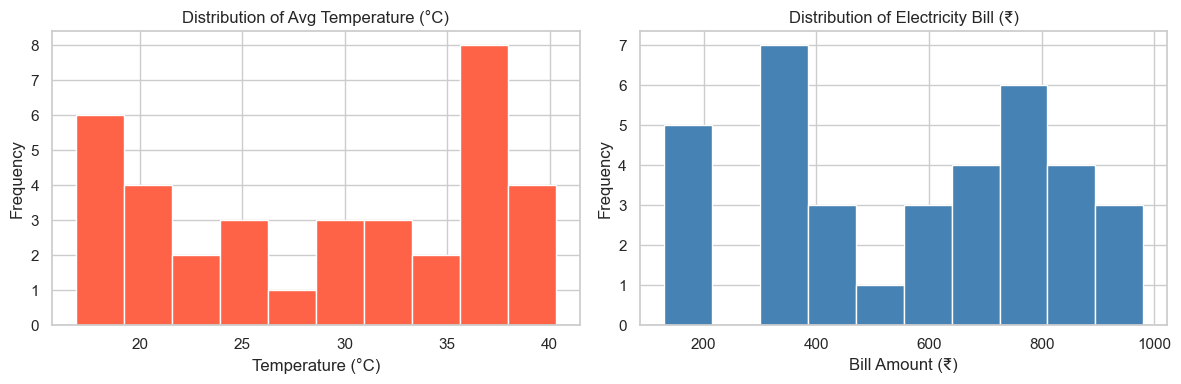

In [5]:
# Distribution of both variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Avg_Temperature_C'], bins=10, color='tomato', edgecolor='white')
axes[0].set_title('Distribution of Avg Temperature (°C)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Electricity_Bill_INR'], bins=10, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Electricity Bill (₹)')
axes[1].set_xlabel('Bill Amount (₹)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


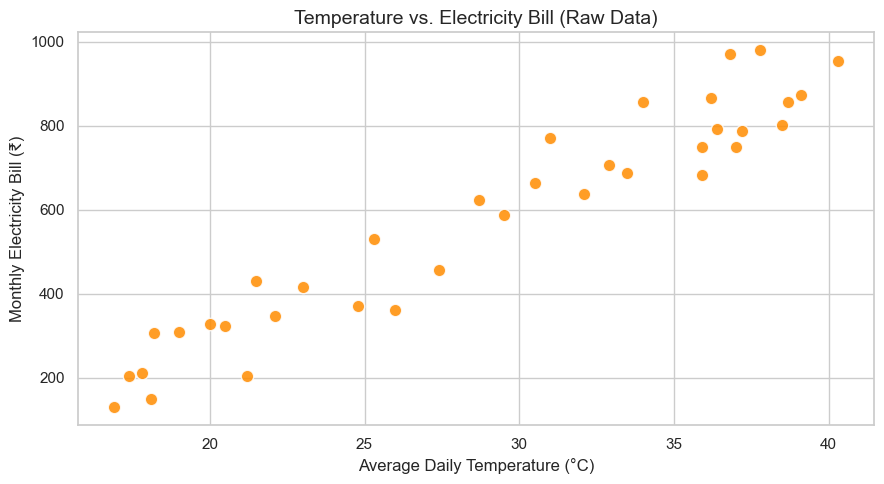


 Pearson Correlation (r): 0.9596
A strong positive correlation — as temperature rises, so does the bill!


In [6]:
# Scatter plot 
plt.figure(figsize=(9, 5))
plt.scatter(df['Avg_Temperature_C'], df['Electricity_Bill_INR'],
            color='darkorange', edgecolors='white', s=80, alpha=0.85)
plt.title('Temperature vs. Electricity Bill (Raw Data)', fontsize=14)
plt.xlabel('Average Daily Temperature (°C)')
plt.ylabel('Monthly Electricity Bill (₹)')
plt.tight_layout()
plt.show()

# Correlation
corr = df['Avg_Temperature_C'].corr(df['Electricity_Bill_INR'])
print(f"\n Pearson Correlation (r): {corr:.4f}")
print("A strong positive correlation — as temperature rises, so does the bill!")

In [7]:
X = df[['Avg_Temperature_C']]  
y = df['Electricity_Bill_INR']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples  : {len(df)}")
print(f"Training set   : {len(X_train)} samples")
print(f"Test set       : {len(X_test)} samples")

Total samples  : 36
Training set   : 28 samples
Test set       : 8 samples


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained! Here are the learned parameters:")
print(f"   Slope (coefficient)  : {model.coef_[0]:.4f}")
print(f"   Intercept            : {model.intercept_:.4f}")
print()
print(f" Regression Equation:")
print(f"   Electricity Bill = {model.coef_[0]:.2f} × Temperature + ({model.intercept_:.2f})")

Model trained! Here are the learned parameters:
   Slope (coefficient)  : 31.2026
   Intercept            : -320.4012

 Regression Equation:
   Electricity Bill = 31.20 × Temperature + (-320.40)


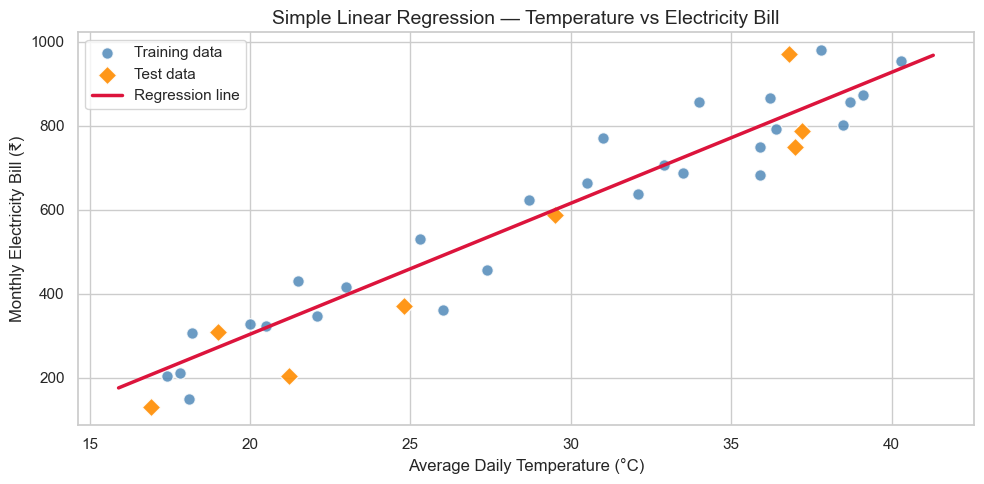

In [9]:
# Predict over a smooth range for the regression line
x_line = np.linspace(X['Avg_Temperature_C'].min() - 1,
                     X['Avg_Temperature_C'].max() + 1, 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='steelblue', label='Training data', s=70, alpha=0.8, edgecolors='white')
plt.scatter(X_test, y_test, color='darkorange', label='Test data', s=90, marker='D', alpha=0.9, edgecolors='white')
plt.plot(x_line, y_line, color='crimson', linewidth=2.5, label='Regression line')

plt.title('Simple Linear Regression — Temperature vs Electricity Bill', fontsize=14)
plt.xlabel('Average Daily Temperature (°C)')
plt.ylabel('Monthly Electricity Bill (₹)')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("Model Performance on Test Set")
print(f"  MAE  (Mean Absolute Error)       : ₹{mae:.2f}")
print(f"  MSE  (Mean Squared Error)        : {mse:.2f}")
print(f"  RMSE (Root Mean Squared Error)   : ₹{rmse:.2f}")
print(f"  R²   (R-Squared Score)           : {r2:.4f}")
print()
print(f"This model explains {r2*100:.1f}% of the variance in electricity bills!")

Model Performance on Test Set
  MAE  (Mean Absolute Error)       : ₹78.65
  MSE  (Mean Squared Error)        : 8014.30
  RMSE (Root Mean Squared Error)   : ₹89.52
  R²   (R-Squared Score)           : 0.9017

This model explains 90.2% of the variance in electricity bills!


In [11]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual Bill (₹)': y_test.values,
    'Predicted Bill (₹)': np.round(y_pred, 2),
    'Error (₹)': np.round(y_test.values - y_pred, 2)
})
comparison.index = range(1, len(comparison)+1)
print(comparison.to_string())

   Actual Bill (₹)  Predicted Bill (₹)  Error (₹)
1           129.33              206.92     -77.59
2           202.94              341.09    -138.15
3           371.92              453.42     -81.50
4           787.86              840.33     -52.47
5           748.97              834.09     -85.12
6           972.18              827.85     144.33
7           586.94              600.07     -13.13
8           309.36              272.45      36.91


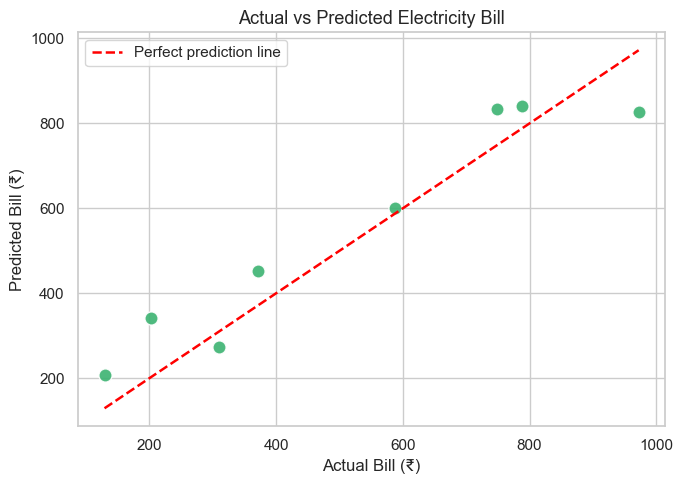

In [12]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='mediumseagreen', s=90, edgecolors='white', alpha=0.9)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1.8, label='Perfect prediction line')
plt.title('Actual vs Predicted Electricity Bill', fontsize=13)
plt.xlabel('Actual Bill (₹)')
plt.ylabel('Predicted Bill (₹)')
plt.legend()
plt.tight_layout()
plt.show()

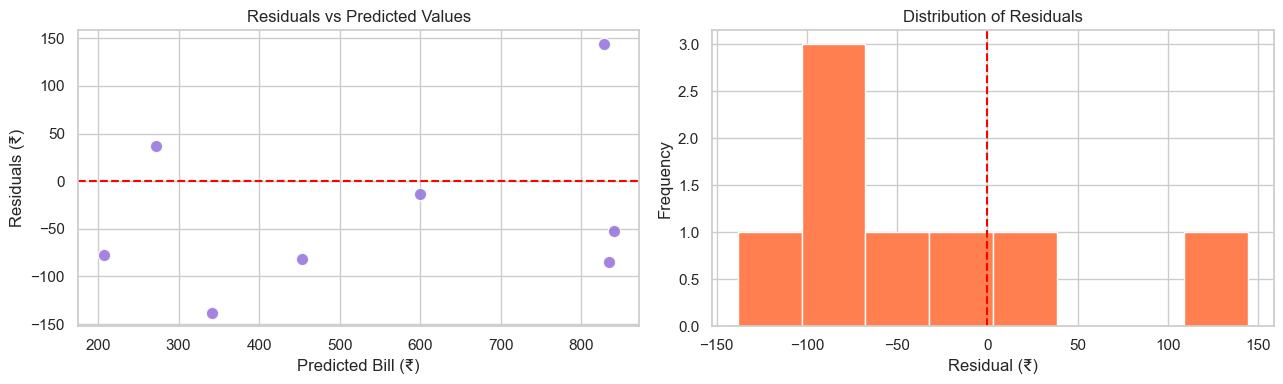

Mean of residuals: -33.3427  (should be close to 0)


In [13]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, color='mediumpurple', edgecolors='white', s=80, alpha=0.85)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Bill (₹)')
axes[0].set_ylabel('Residuals (₹)')

# Residual distribution
axes[1].hist(residuals, bins=8, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual (₹)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}  (should be close to 0)")